In [142]:
import pandas as pd

df = pd.read_parquet("../data_files/ecq_sha_B_100_conds_1_500000_reg.parquet")

### Poke around the data

In [3]:
print(df.head())

         2        3        5        7       11      13       17       19  \
0 -0.70711 -0.28868  0.22361 -0.37796  0.15076  0.5547 -0.24254  0.00000   
1 -0.70711 -0.28868  0.22361 -0.37796  0.15076  0.5547 -0.24254  0.00000   
2 -0.70711 -0.28868  0.22361 -0.37796  0.15076  0.5547 -0.24254  0.00000   
3 -0.35355 -0.57735  0.00000  0.18898  0.00000 -0.5547  0.72761  0.22942   
4 -0.35355 -0.57735  0.00000  0.18898  0.00000 -0.5547  0.72761  0.22942   

        23       29  ...  tamagawa_product  kodaira_-5.0  kodaira_-4.0  \
0 -0.10426  0.00000  ...                 1             0             0   
1 -0.10426  0.00000  ...                 5             0             0   
2 -0.10426  0.00000  ...                 1             0             0   
3  0.00000 -0.55709  ...                 2             0             0   
4  0.00000 -0.55709  ...                 2             0             0   

   kodaira_-3.0  kodaira_-2.0  kodaira_-1.0  kodaira_2.0  kodaira_3.0  \
0             0          

In [83]:
print(df.columns.values)

['2' '3' '5' '7' '11' '13' '17' '19' '23' '29' '31' '37' '41' '43' '47'
 '53' '59' '61' '67' '71' '73' '79' '83' '89' '97' '101' '103' '107' '109'
 '113' '127' '131' '137' '139' '149' '151' '157' '163' '167' '173' '179'
 '181' '191' '193' '197' '199' '211' '223' '227' '229' '233' '239' '241'
 '251' '257' '263' '269' '271' '277' '281' '283' '293' '307' '311' '313'
 '317' '331' '337' '347' '349' '353' '359' '367' '373' '379' '383' '389'
 '397' '401' '409' '419' '421' '431' '433' '439' '443' '449' '457' '461'
 '463' '467' '479' '487' '491' '499' '503' '509' '521' '523' '541'
 'conductor' 'rank' 'torsion' 'adelic_level' 'adelic_index' 'adelic_genus'
 'sha' 'real_period' 'special_value' 'tamagawa_product' 'kodaira_-5.0'
 'kodaira_-4.0' 'kodaira_-3.0' 'kodaira_-2.0' 'kodaira_-1.0' 'kodaira_2.0'
 'kodaira_3.0' 'kodaira_4.0' 'kodaira_5.0']


In [143]:
df.shape

(3064705, 119)

In [13]:
df['rank'].value_counts()

rank
1    1535669
0    1170876
2     348672
3       9487
4          1
Name: count, dtype: int64

In [16]:
df['sha'].value_counts()

sha
1       2821178
4        158758
9         50428
16        18170
25         8501
36         2402
49         2153
64         1301
81          595
100         315
121         300
169         160
144         145
196          58
256          45
225          43
289          34
361          29
400          15
529          13
625          12
324           7
784           7
441           5
1024          4
729           4
576           4
676           3
841           3
961           3
484           2
1681          1
5625          1
2500          1
2209          1
1089          1
1849          1
1369          1
1156          1
Name: count, dtype: int64

In [144]:
df = df.loc[df['sha'] <= 16]
df = df.loc[df['rank'] <= 3]

In [145]:
df.shape
df['rank'].value_counts()

rank
1    1535559
0    1154815
2     348672
3       9487
Name: count, dtype: int64

In [129]:
df['sha'].value_counts()

sha
1     2821177
4      158758
9       50428
16      18170
Name: count, dtype: int64

In [146]:
y = df['sha']
y_1 = df['rank']
df.drop(['sha'], axis=1, inplace=True)
X = df

In [147]:
X.head()

,2,3,5,7,11,13,17,19,23,29,...,tamagawa_product,kodaira_-5.0,kodaira_-4.0,kodaira_-3.0,kodaira_-2.0,kodaira_-1.0,kodaira_2.0,kodaira_3.0,kodaira_4.0,kodaira_5.0
0,-0.70711,-0.28868,0.22361,-0.37796,0.15076,0.5547,-0.24254,0.00000,-0.10426,0.00000,...,1,0,0,0,0,0,0,0,0,1
1,-0.70711,-0.28868,0.22361,-0.37796,0.15076,0.5547,-0.24254,0.00000,-0.10426,0.00000,...,5,0,0,0,0,0,0,0,0,1
2,-0.70711,-0.28868,0.22361,-0.37796,0.15076,0.5547,-0.24254,0.00000,-0.10426,0.00000,...,1,0,0,0,0,0,0,0,0,1
3,-0.35355,-0.57735,0.00000,0.18898,0.00000,-0.5547,0.72761,0.22942,0.00000,-0.55709,...,2,0,0,0,0,0,0,0,0,1
4,-0.35355,-0.57735,0.00000,0.18898,0.00000,-0.5547,0.72761,0.22942,0.00000,-0.55709,...,2,0,0,0,0,0,0,0,0,1


In [148]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

### PCA plots

In [149]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X)

In [150]:
pca_X = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])
print(pca_X.head())

   principal component 1  principal component 2
0              -9.298630              21.619243
1              -9.748513              22.777947
2              -8.094368              21.571674
3              -6.591898              13.706531
4              -6.591898              13.706531


In [151]:
y.reset_index(drop=True, inplace=True)
y_1.reset_index(drop=True, inplace=True)
pca_X.reset_index(drop=True, inplace=True)
pca_df = pd.concat([pca_X, y, y_1], axis = 1)
pca_X.shape
pca_df.shape

(3048533, 4)

In [152]:
pca_df.head()

,principal component 1,principal component 2,sha,rank
0,-9.298630,21.619243,1,0
1,-9.748513,22.777947,1,0
2,-8.094368,21.571674,1,0
3,-6.591898,13.706531,1,0
4,-6.591898,13.706531,1,0


In [153]:
pca.explained_variance_ratio_

array([0.02096892, 0.017463  ])

In [154]:
pca_df["sha"].value_counts()

sha
1     2821177
4      158758
9       50428
16      18170
Name: count, dtype: int64

In [155]:
pca_df_partial = pca_df
pca_df_partial["sha"].value_counts()

sha
1     2821177
4      158758
9       50428
16      18170
Name: count, dtype: int64

/var/folders/5z/bkq51n716tl9q2b0n87tht1r0000gn/T/ipykernel_9086/1486964019.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pca_df_partial.loc[indicesToKeep, 'principal component 1']


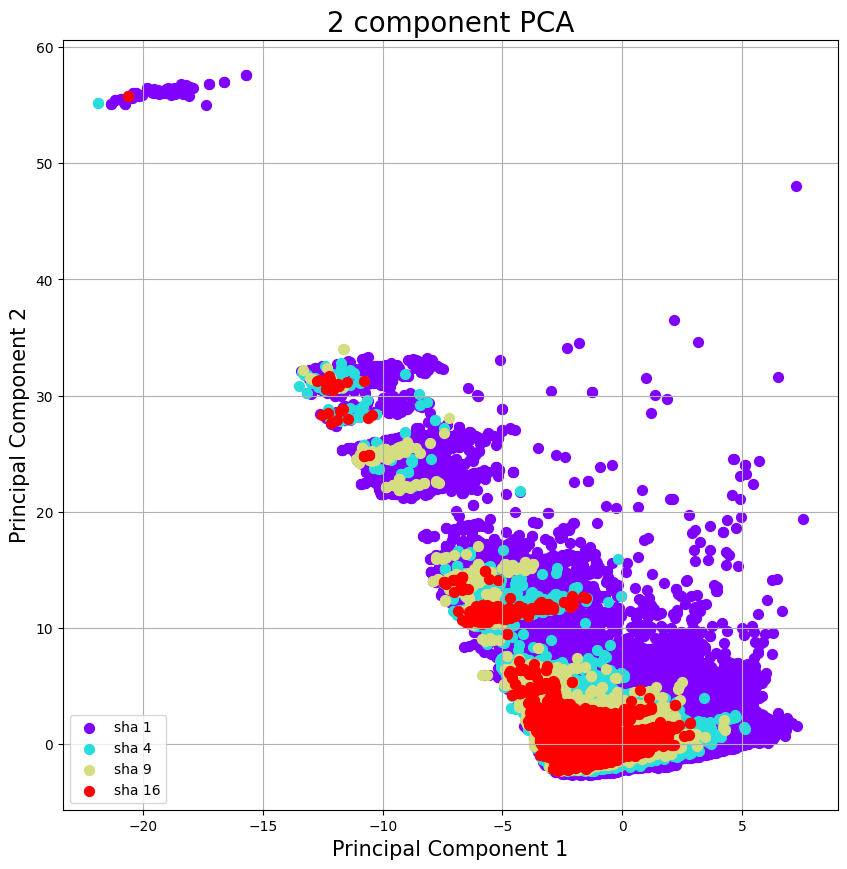

In [156]:
import matplotlib.pyplot as plt 
from matplotlib.pyplot import cm
import numpy as np

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)

sha_values = np.array([1, 4, 9, 16])
color = iter(cm.rainbow(np.linspace(0, 1, sha_values.size)))
for sha in sha_values:
    indicesToKeep = pca_df_partial['sha'] == sha
    ax.scatter(pca_df_partial.loc[indicesToKeep, 'principal component 1']
               , pca_df_partial.loc[indicesToKeep, 'principal component 2']
               , c = next(color)
               , s = 50,
               label="sha " + str(sha))
    
ax.legend(loc="lower left")
ax.grid()
plt.savefig('plot-pca.png')

/var/folders/5z/bkq51n716tl9q2b0n87tht1r0000gn/T/ipykernel_9086/3191260285.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pca_df_partial.loc[indicesToKeep, 'principal component 1']


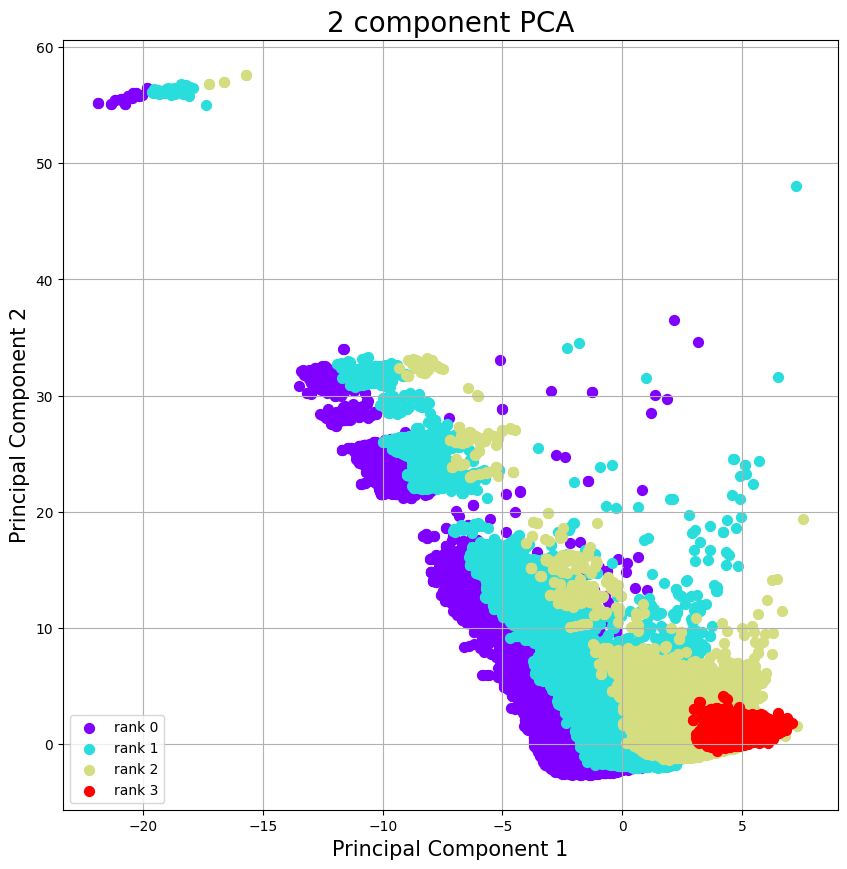

In [157]:
import matplotlib.pyplot as plt 
from matplotlib.pyplot import cm
import numpy as np

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)

rank_values = np.array([0, 1, 2, 3])
color = iter(cm.rainbow(np.linspace(0, 1, rank_values.size)))
for rank in rank_values:
    indicesToKeep = pca_df_partial['rank'] == rank
    ax.scatter(pca_df_partial.loc[indicesToKeep, 'principal component 1']
               , pca_df_partial.loc[indicesToKeep, 'principal component 2']
               , c = next(color)
               , s = 50,
               label="rank " + str(rank))
    
ax.legend(loc="lower left")
ax.grid()
plt.savefig('plot-pca.png')